In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
from kaggle_secrets import UserSecretsClient
secret_label = "github_token"
TOKEN = UserSecretsClient().get_secret(secret_label)

In [17]:
!rm -rf /kaggle/working/vad_unified


In [18]:
import subprocess, sys



# Clone the unified repo
REPO_URL = f"https://{TOKEN}@github.com/PaulOkwija/vad_unified.git"  # ← update this
REPO_DIR = "/kaggle/working/vad_unified"

import os
if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

# Add repo to Python path
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Install dependencies
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "einops",
    "scikit-learn",
    "scipy",
    "tqdm",
    "git+https://github.com/openai/CLIP.git",
], check=True)

print("Setup complete.")

Cloning into '/kaggle/working/vad_unified'...


Setup complete.


# Data Preparation
- Unique to this dataset: https://www.kaggle.com/datasets/adityagaikwad9552/ucf-crime-splitted-i3d-features
- We are using it because it is readily available and in the I3D format

In [19]:
from pathlib import Path

DATASET_ROOT  = Path("/kaggle/input/datasets/adityagaikwad9552/ucf-crime-splitted-i3d-features")
PROCESSED_DIR = Path("/kaggle/working/processed_features")
LISTS_DIR     = Path("/kaggle/working/lists")
NUM_SEGMENTS  = 32
FEAT_DIM      = 1024

print(f"Dataset root  : {DATASET_ROOT}")
print(f"Processed dir : {PROCESSED_DIR}")
print(f"Lists dir     : {LISTS_DIR}")

Dataset root  : /kaggle/input/datasets/adityagaikwad9552/ucf-crime-splitted-i3d-features
Processed dir : /kaggle/working/processed_features
Lists dir     : /kaggle/working/lists


In [20]:
from pathlib import Path
import numpy as np

print("=== Dataset tree (first 3 files per partition) ===")
for split in ["train", "test"]:
    for label in ["anomaly", "normal"]:
        p = DATASET_ROOT / split / label
        if not p.exists():
            print(f"  MISSING: {p}")
            continue
        vid_dirs = sorted(p.iterdir())
        print(f"\n{split}/{label}:  {len(vid_dirs)} video folders")
        for vd in vid_dirs[:2]:
            files = sorted(vd.iterdir())
            print(f"  {vd.name}/  ({len(files)} seq files)")
            for f in files[:3]:
                arr = np.load(f)
                if hasattr(arr, 'files'):
                    arr = arr[arr.files[0]]
                print(f"    {f.name}  shape={arr.shape}")

=== Dataset tree (first 3 files per partition) ===

train/anomaly:  665 video folders
  Abuse003_x264.mp4/  (64 seq files)
    seq_0.npz  shape=(7, 1, 1, 1024)
    seq_1.npz  shape=(7, 1, 1, 1024)
    seq_10.npz  shape=(7, 1, 1, 1024)
  Abuse005_x264.mp4/  (16 seq files)
    seq_0.npz  shape=(7, 1, 1, 1024)
    seq_1.npz  shape=(7, 1, 1, 1024)
    seq_10.npz  shape=(7, 1, 1, 1024)

train/normal:  665 video folders
  Normal_Videos001_x264.mp4/  (9 seq files)
    seq_0.npz  shape=(7, 1, 1, 1024)
    seq_1.npz  shape=(7, 1, 1, 1024)
    seq_2.npz  shape=(7, 1, 1, 1024)
  Normal_Videos004_x264.mp4/  (16 seq files)
    seq_0.npz  shape=(7, 1, 1, 1024)
    seq_1.npz  shape=(7, 1, 1, 1024)
    seq_10.npz  shape=(7, 1, 1, 1024)

test/anomaly:  142 video folders
  Abuse006_x264.mp4/  (76 seq files)
    seq_0.npz  shape=(7, 1, 1, 1024)
    seq_1.npz  shape=(7, 1, 1, 1024)
    seq_10.npz  shape=(7, 1, 1, 1024)
  Abuse026_x264.mp4/  (34 seq files)
    seq_0.npz  shape=(7, 1, 1, 1024)
    seq_1.npz

### Preprocess features → `[32, 1024]` per video

Merges all `seq_*.npz` files for each video into a single pooled array.
Wipes any previous output to avoid stale files with wrong shapes.

In [21]:
import sys
sys.path.insert(0, "/kaggle/working/vad_unified")
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s")

from scripts.build_data import preprocess_features

preprocess_features(
    dataset_root  = DATASET_ROOT,
    processed_dir = PROCESSED_DIR,
    num_segments  = NUM_SEGMENTS,
    feat_dim      = FEAT_DIM,
)
print("Done.")

2026-03-14 17:08:11,050 Cleared and recreated: /kaggle/working/processed_features
2026-03-14 17:08:11,068 Detected feature extension: .npz
2026-03-14 17:20:50,413 Processed 1615 videos. Errors: 0        
2026-03-14 17:20:50,415 Sample shape OK: (32, 1024)


Done.


### Build list files

In [22]:
from scripts.build_data import build_list_files

train_list, test_list, stats = build_list_files(PROCESSED_DIR, LISTS_DIR)
print(f"train.list: {stats['train'][0]} anomaly + {stats['train'][1]} normal")
print(f"test.list : {stats['test'][0]} anomaly + {stats['test'][1]} normal")
print("\nFirst 3 lines of test.list:")
with open(test_list) as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f"  {line.strip()}")

2026-03-14 17:20:50,436   train.list: 665 anomaly + 665 normal = 1330
2026-03-14 17:20:50,440   test.list: 142 anomaly + 143 normal = 285


train.list: 665 anomaly + 665 normal
test.list : 142 anomaly + 143 normal

First 3 lines of test.list:
  /kaggle/working/processed_features/test/anomaly/Abuse006_x264.mp4.npy
  /kaggle/working/processed_features/test/anomaly/Abuse026_x264.mp4.npy
  /kaggle/working/processed_features/test/anomaly/Abuse027_x264.mp4.npy


In [23]:
from scripts.build_data import build_gt
import numpy as np

gt_path = build_gt(PROCESSED_DIR, LISTS_DIR, NUM_SEGMENTS)
gt = np.load(gt_path)
print(f"GT shape : {gt.shape}")
print(f"Anomaly  : {gt.sum():,} / {len(gt):,} frames  ({100*gt.mean():.1f}%)")

2026-03-14 17:20:50,459 GT: shape=(145920,)  (142 abn + 143 nrm = 285 test videos)


GT shape : (145920,)
Anomaly  : 72,704 / 145,920 frames  (49.8%)


## Build CLIP text embeddings

Encodes 14 class-name prompts with CLIP ViT-B/32 → `[14, 512]` array.
Required by PEL4VAD's prompt-enhanced contrastive loss.

In [24]:
from scripts.build_data import build_clip_prompts
from configs.base import UCF_CLASSES
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
prompt_path = build_clip_prompts(LISTS_DIR, UCF_CLASSES, device=device)
print("Classes encoded:", UCF_CLASSES)

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 202MiB/s]
2026-03-14 17:20:56,702 CLIP prompts: shape=(14, 512)  saved → /kaggle/working/lists/ucf_prompt.npy


Classes encoded: ['Normal', 'Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']


In [25]:
import numpy as np
from pathlib import Path

print("=" * 50)
print("SANITY CHECKS")
print("=" * 50)

# 1. Feature shapes (random sample)
import random
all_npy = list(Path(PROCESSED_DIR).rglob("*.npy"))
bad = 0
for fp in random.sample(all_npy, min(10, len(all_npy))):
    f = np.load(fp)
    ok = f.shape == (NUM_SEGMENTS, FEAT_DIM)
    if not ok:
        bad += 1
        print(f"  ✗ {fp.name}  shape={f.shape}")
print(f"[1] Feature shapes: {len(all_npy)-bad}/{len(all_npy)} correct ({NUM_SEGMENTS}, {FEAT_DIM})")

# 2. List files
for lf in [LISTS_DIR / "train.list", LISTS_DIR / "test.list"]:
    lines = Path(lf).read_text().strip().splitlines()
    missing = sum(1 for l in lines if not Path(l).exists())
    print(f"[2] {lf.name}: {len(lines)} entries, {missing} missing")

# 3. GT
gt = np.load(LISTS_DIR / "ucf_gt.npy")
test_lines = (LISTS_DIR / "test.list").read_text().strip().splitlines()
expected = len(test_lines) * NUM_SEGMENTS * 16
ok = len(gt) == expected
print(f"[3] GT shape: {gt.shape}  expected=({expected},)  {'✓' if ok else '✗'}")

# 4. Prompts
pf = np.load(LISTS_DIR / "ucf_prompt.npy")
print(f"[4] Prompts shape: {pf.shape}  expected=(14, 512)  {'✓' if pf.shape==(14,512) else '✗'}")

print("\nAll checks done. You're ready for Notebook 2.")

SANITY CHECKS
[1] Feature shapes: 1615/1615 correct (32, 1024)
[2] train.list: 1330 entries, 0 missing
[2] test.list: 285 entries, 0 missing
[3] GT shape: (145920,)  expected=(145920,)  ✓
[4] Prompts shape: (14, 512)  expected=(14, 512)  ✓

All checks done. You're ready for Notebook 2.


# Training of models

In [26]:
import sys, os
# REPO_DIR = "/kaggle/working/vad_unified"
# if REPO_DIR not in sys.path:
#     sys.path.insert(0, REPO_DIR)

# ── Choose which models to run ─────────────────────────────────────────
RUN_MODELS = ["pel4vad", "mgfn"]   # or just ["pel4vad"] / ["mgfn"]

# ── Paths (must match Notebook 1 outputs) ──────────────────────────────
from pathlib import Path
PROCESSED_DIR = Path("/kaggle/working/processed_features")
LISTS_DIR     = Path("/kaggle/working/lists")
RESULTS_DIR   = Path("/kaggle/working/results")
RESULTS_DIR.mkdir(exist_ok=True)

# ── Epoch counts (reduce for a quick test run) ──────────────────────────
EPOCHS = {"pel4vad": 50, "mgfn": 100}

print("Models to train:", RUN_MODELS)
print("Results dir    :", RESULTS_DIR)

Models to train: ['pel4vad', 'mgfn']
Results dir    : /kaggle/working/results


In [27]:
import subprocess
# subprocess.run([sys.executable, "-m", "pip", "install", "-q",
#     "einops", "scikit-learn", "scipy", "tqdm",
#     "git+https://github.com/openai/CLIP.git",
# ], check=True)

import torch
import numpy as np
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s")

from configs import get_config
from models  import build_model
from datasets.ucf_dataset import UCFDataset
from torch.utils.data import DataLoader
from engine.trainer   import train as train_model
from engine.evaluator import evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'}")

PyTorch 2.9.0+cu126 | GPU: Tesla P100-PCIE-16GB


In [28]:
def build_loaders(model_name, cfg, clip_feats=None):
    """Return (train_loader, test_loader) — and train_aloader for MGFN."""
    if model_name == "pel4vad":
        train_ds = UCFDataset(cfg, test_mode=False, model_name="pel4vad",
                              clip_feats=clip_feats)
        test_ds  = UCFDataset(cfg, test_mode=True,  model_name="pel4vad")
        train_loader = DataLoader(train_ds, batch_size=cfg["train_bs"],
                                  shuffle=True, num_workers=cfg["workers"],
                                  pin_memory=True, drop_last=True)
        test_loader  = DataLoader(test_ds,  batch_size=cfg["test_bs"],
                                  shuffle=False, num_workers=0, pin_memory=True)
        return train_loader, test_loader, None

    elif model_name == "mgfn":
        train_nds = UCFDataset(cfg, test_mode=False, model_name="mgfn", is_normal=True)
        train_ads = UCFDataset(cfg, test_mode=False, model_name="mgfn", is_normal=False)
        test_ds   = UCFDataset(cfg, test_mode=True,  model_name="mgfn")
        bs = cfg["batch_size"]
        nloader = DataLoader(train_nds, batch_size=bs, shuffle=False,
                             num_workers=cfg["workers"], pin_memory=False, drop_last=True)
        aloader = DataLoader(train_ads, batch_size=bs, shuffle=False,
                             num_workers=cfg["workers"], pin_memory=False, drop_last=True)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                                 num_workers=0, pin_memory=False)
        return nloader, test_loader, aloader

In [29]:
import numpy as np

gt          = np.load(LISTS_DIR / "ucf_gt.npy")
clip_feats  = np.load(LISTS_DIR / "ucf_prompt.npy")   # [14, 512], PEL4VAD only

print(f"GT shape     : {gt.shape}")
print(f"CLIP prompts : {clip_feats.shape}")

GT shape     : (145920,)
CLIP prompts : (14, 512)


In [30]:
all_histories = {}

for model_name in RUN_MODELS:
    print("\n" + "="*60)
    print(f"  Training {model_name.upper()}")
    print("="*60)

    cfg = get_config(model_name, overrides={
        "feat_prefix": str(PROCESSED_DIR),
        "train_list":  str(LISTS_DIR / "train.list"),
        "test_list":   str(LISTS_DIR / "test.list"),
        "token_feat":  str(LISTS_DIR / "ucf_prompt.npy"),
        "gt":          str(LISTS_DIR / "ucf_gt.npy"),
        "save_dir":    str(RESULTS_DIR / model_name) + "/",
        "logs_dir":    str(RESULTS_DIR / f"{model_name}_train.log"),
        "max_epoch":   EPOCHS[model_name],
        "workers":     4,
    })

    train_loader, test_loader, train_aloader = build_loaders(
        model_name, cfg, clip_feats=(clip_feats if model_name == "pel4vad" else None)
    )

    model = build_model(model_name, cfg).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {n_params/1e6:.2f}M")

    history = train_model(
        model_name    = model_name,
        model         = model,
        train_loader  = train_loader,
        gt            = gt,
        cfg           = cfg,
        device        = device,
        test_loader   = test_loader,
        train_aloader = train_aloader,
    )
    all_histories[model_name] = (history, model, cfg)
    best_auc = max(history["auc"])
    best_pr  = max(history["pr_auc"])
    print(f"\n✓ {model_name.upper()} | Best AUC: {best_auc:.4f}  PR-AUC: {best_pr:.4f}")

2026-03-14 17:20:56,824 Starting PEL4VAD training — 50 epochs



  Training PEL4VAD
Parameters: 1.21M


2026-03-14 17:21:02,085 [001/50] loss=0.7273 | AUC=0.8163  PR=0.8283  FAR=0.00000 | 0.1min
2026-03-14 17:21:02,099   ✓ New best AUC 0.8163 → pel4vad_8163.pkl
2026-03-14 17:21:06,416 [002/50] loss=0.5098 | AUC=0.8801  PR=0.8904  FAR=0.00000 | 0.2min
2026-03-14 17:21:06,427   ✓ New best AUC 0.8801 → pel4vad_8801.pkl
2026-03-14 17:21:10,635 [003/50] loss=0.4022 | AUC=0.8701  PR=0.8720  FAR=0.00000 | 0.2min
2026-03-14 17:21:14,821 [004/50] loss=0.3653 | AUC=0.8960  PR=0.9061  FAR=0.00000 | 0.3min
2026-03-14 17:21:14,832   ✓ New best AUC 0.8960 → pel4vad_896.pkl
2026-03-14 17:21:19,083 [005/50] loss=0.2728 | AUC=0.8760  PR=0.8780  FAR=0.00000 | 0.4min
2026-03-14 17:21:23,232 [006/50] loss=0.2422 | AUC=0.8939  PR=0.9019  FAR=0.00000 | 0.4min
2026-03-14 17:21:27,525 [007/50] loss=0.2311 | AUC=0.8879  PR=0.8931  FAR=0.00000 | 0.5min
2026-03-14 17:21:31,743 [008/50] loss=0.1988 | AUC=0.8908  PR=0.8959  FAR=0.00000 | 0.6min
2026-03-14 17:21:36,282 [009/50] loss=0.1554 | AUC=0.8906  PR=0.8959  FA


✓ PEL4VAD | Best AUC: 0.9020  PR-AUC: 0.9061

  Training MGFN


2026-03-14 17:24:28,230 Starting MGFN training — 100 epochs


Parameters: 28.46M


2026-03-14 17:24:34,807 [001/100] loss=0.9089 | AUC=0.7423  PR=0.7041  FAR=0.00000 | 0.1min
2026-03-14 17:24:34,945   ✓ New best AUC 0.7423 → mgfn_7423.pkl
2026-03-14 17:24:41,276 [002/100] loss=0.7583 | AUC=0.8727  PR=0.8832  FAR=0.00000 | 0.2min
2026-03-14 17:24:41,408   ✓ New best AUC 0.8727 → mgfn_8727.pkl
2026-03-14 17:24:47,847 [003/100] loss=0.6432 | AUC=0.8753  PR=0.8830  FAR=0.00000 | 0.3min
2026-03-14 17:24:47,984   ✓ New best AUC 0.8753 → mgfn_8753.pkl
2026-03-14 17:24:54,390 [004/100] loss=0.5877 | AUC=0.8846  PR=0.8976  FAR=0.00000 | 0.4min
2026-03-14 17:24:54,533   ✓ New best AUC 0.8846 → mgfn_8846.pkl
2026-03-14 17:25:00,831 [005/100] loss=0.5592 | AUC=0.8911  PR=0.9003  FAR=0.00000 | 0.5min
2026-03-14 17:25:00,972   ✓ New best AUC 0.8911 → mgfn_8911.pkl
2026-03-14 17:25:07,425 [006/100] loss=0.5369 | AUC=0.8737  PR=0.8856  FAR=0.00000 | 0.7min
2026-03-14 17:25:13,884 [007/100] loss=0.4998 | AUC=0.8911  PR=0.9082  FAR=0.00000 | 0.8min
2026-03-14 17:25:20,253 [008/100] lo


✓ MGFN | Best AUC: 0.9020  PR-AUC: 0.9167


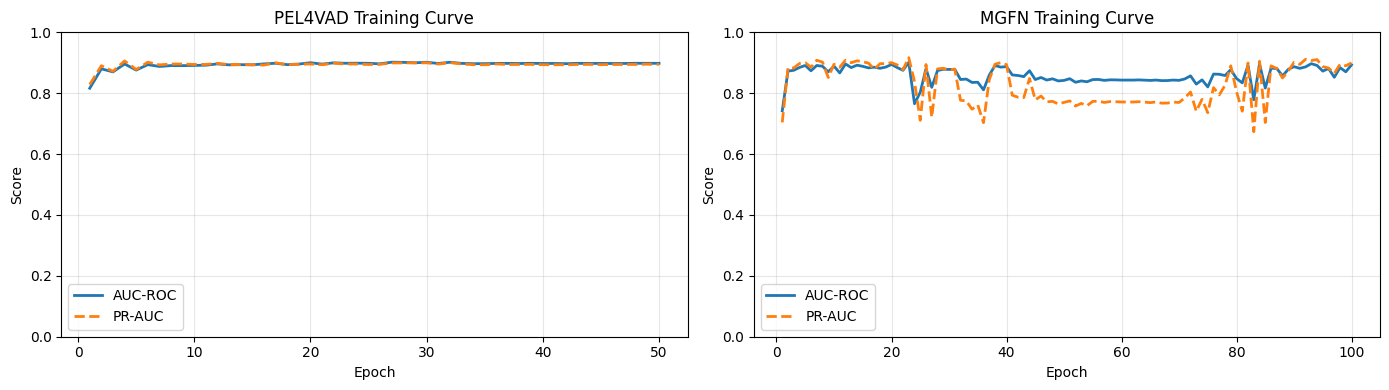

Saved → /kaggle/working/results/training_curves.png


In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(RUN_MODELS), figsize=(7*len(RUN_MODELS), 4))
if len(RUN_MODELS) == 1:
    axes = [axes]

for ax, model_name in zip(axes, RUN_MODELS):
    history, _, _ = all_histories[model_name]
    epochs = history["epoch"]
    ax.plot(epochs, history["auc"],    label="AUC-ROC", linewidth=2)
    ax.plot(epochs, history["pr_auc"], label="PR-AUC",  linewidth=2, linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_title(f"{model_name.upper()} Training Curve")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()
print(f"Saved → {RESULTS_DIR}/training_curves.png")

In [32]:
import pandas as pd
from pathlib import Path

rows = []
for model_name in RUN_MODELS:
    history, model, cfg = all_histories[model_name]
    # Load best checkpoint for clean eval
    ckpt_dir = Path(cfg["save_dir"])
    ckpts    = sorted(ckpt_dir.glob(f"{model_name}_*.pkl"),
                      key=lambda p: p.stat().st_mtime)
    if ckpts:
        state = {k.replace("module.", ""): v
                 for k, v in torch.load(ckpts[-1], map_location=device).items()}
        model.load_state_dict(state)
        print(f"Loaded best checkpoint: {ckpts[-1].name}")

    test_ds     = UCFDataset(cfg, test_mode=True, model_name=model_name)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

    roc_auc, pr_auc, far = evaluate(model, test_loader, gt, model_name, cfg, device)
    best_epoch = history["epoch"][history["auc"].index(max(history["auc"]))]
    rows.append({
        "Model":      model_name.upper(),
        "AUC-ROC":    f"{roc_auc*100:.2f}%",
        "PR-AUC":     f"{pr_auc*100:.2f}%",
        "FAR@0.5":    f"{far*100:.2f}%",
        "Best Epoch": best_epoch,
        "Params":     f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M",
    })
    print(f"{model_name.upper():10s}  AUC={roc_auc*100:.2f}%  PR={pr_auc*100:.2f}%  FAR={far*100:.2f}%")

df = pd.DataFrame(rows)
print("\n" + df.to_string(index=False))
df.to_csv(RESULTS_DIR / "comparison.csv", index=False)
print(f"\nSaved → {RESULTS_DIR}/comparison.csv")

Loaded best checkpoint: pel4vad_902.pkl
PEL4VAD     AUC=90.20%  PR=89.94%  FAR=0.00%
Loaded best checkpoint: mgfn_902.pkl
MGFN        AUC=90.20%  PR=91.67%  FAR=0.00%

  Model AUC-ROC PR-AUC FAR@0.5  Best Epoch Params
PEL4VAD  90.20% 89.94%   0.00%          27  1.21M
   MGFN  90.20% 91.67%   0.00%          23 28.46M

Saved → /kaggle/working/results/comparison.csv


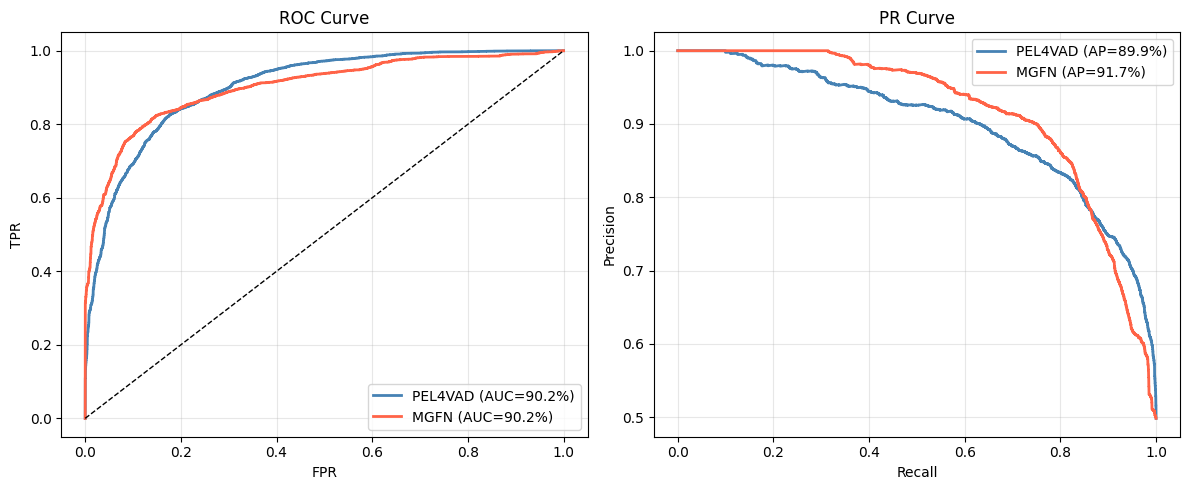

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from torch.utils.data import DataLoader
from datasets.ucf_dataset import UCFDataset
from engine.evaluator import slide_smooth, fixed_smooth

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
COLORS = {"pel4vad": "steelblue", "mgfn": "tomato"}

for model_name in RUN_MODELS:
    _, model, cfg = all_histories[model_name]
    model.eval()

    test_ds     = UCFDataset(cfg, test_mode=True, model_name=model_name)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
    all_preds   = []

    with torch.no_grad():
        for v_input, _ in test_loader:
            v_input = v_input.float().to(device)
            if model_name == "pel4vad":
                seq_len = torch.sum(torch.max(torch.abs(v_input), dim=2)[0] > 0, 1)
                logits, _ = model(v_input, seq_len)
                scores = torch.mean(logits, 0).squeeze(-1)
                scores = slide_smooth(scores, cfg.get("kappa", 7))
            else:
                feat_m = v_input.unsqueeze(1)              # [1, 1, T, C+1]  ← add n_crops here
                scores = model(feat_m, test_mode=True)
                scores = scores.squeeze(0)
            all_preds.extend(scores.cpu().numpy().tolist())

    pred_frame = np.repeat(np.array(all_preds), 16)[:len(gt)]
    color = COLORS.get(model_name, "gray")

    fpr, tpr, _ = roc_curve(gt, pred_frame)
    roc_auc     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{model_name.upper()} (AUC={roc_auc*100:.1f}%)")

    pre, rec, _ = precision_recall_curve(gt, pred_frame)
    pr_auc      = auc(rec, pre)
    axes[1].plot(rec, pre, color=color, lw=2,
                 label=f"{model_name.upper()} (AP={pr_auc*100:.1f}%)")

axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curve"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_pr_curves.png", dpi=150)
plt.show()

# Evaluation

In [34]:
from pathlib import Path
RESULTS_DIR = Path("/kaggle/working/results")
print("Ready.")

Ready.


In [35]:
from inference.predict import VideoPredictor

MODEL_NAME = "pel4vad"    # ← change to "mgfn" to use MGFN
THRESHOLD  = 0.5          # ← anomaly score threshold

# Auto-find best checkpoint
import glob
ckpts = sorted(glob.glob(str(RESULTS_DIR / MODEL_NAME / "*.pkl")),
               key=lambda p: float("0." + Path(p).stem.split("_")[-1]))
if not ckpts:
    raise FileNotFoundError(f"No checkpoint found in {RESULTS_DIR}/{MODEL_NAME}/. Run Notebook 2 first.")

CKPT_PATH = ckpts[-1]
print(f"Using checkpoint: {Path(CKPT_PATH).name}")

predictor = VideoPredictor(
    model_name = MODEL_NAME,
    ckpt_path  = CKPT_PATH,
    threshold  = THRESHOLD,
)

Using checkpoint: pel4vad_9057.pkl
✓ Loaded PEL4VAD from pel4vad_9057.pkl on cuda


In [38]:
# ── Set your video path here ──────────────────────────────────────────────────
# You can also point to a processed .npy:
# VIDEO_PATH = "/kaggle/working/processed_features/test/anomaly/Abuse028_x264.mp4.npy"
# Or a raw video (requires video_features to be installed):
# VIDEO_PATH = "/kaggle/input/datasets/tesisjulinwilson/ucf-crimes-dataset/UCFcrimes/Fight/Abuse001_x264.mp4"
VIDEO_PATH = "/kaggle/input/datasets/paulmugume/pevid-dataset/PEViD-HD/stealing_night_outdoor_1_1.mpg"
# ─────────────────────────────────────────────────────────────────────────────

result = predictor.predict(VIDEO_PATH)

print("\n" + "="*40)
print(f"  Verdict  : {result['label']}")
print(f"  Max score: {result['max_score']:.4f}")
print(f"  Mean score: {result['mean_score']:.4f}")
print(f"  Threshold: {result['threshold_used']}")
if result['anomalous_segments']:
    print(f"  Anomalous segments: {result['anomalous_segments']}")
print("="*40)

Loaded I3D rgb model from /kaggle/working/vad_unified/video_features/models/i3d/checkpoints/i3d_rgb.pt
Extracting I3D features from /kaggle/input/datasets/paulmugume/pevid-dataset/PEViD-HD/stealing_night_outdoor_1_1.mpg
Extracted 6 feature vectors of shape (1024,)

  Verdict  : ANOMALY
  Max score: 0.7888
  Mean score: 0.4404
  Threshold: 0.5
  Anomalous segments: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
